# 📅 Day 032: Sigmoid, Odds & Log-Odds (Demystified! 🚀)

Hey Sahil! Bilkul tension mat lo. Logistic Regression looks scary because of terms like "Sigmoid", "Odds", and "Log-Odds", but it is actually one of the most beautiful and logical algorithms.

Let's break it down together step-by-step.

---

### 1. The Core Idea: Why not Linear Regression?
In Phase 2, you mastered **Linear Regression**. It predicts continuous values like House Prices ($Y \in (-\infty, \infty)$) using a straight line:
$$z = \beta_0 + \beta_1 x$$

But what if we want to classify if a person has Diabetes (Yes=1, No=0)?
- If we use a straight line, it can output values like $1.5$ or $-0.8$.
- But probability $p$ must be strictly between **0 and 1**!
- We need a mathematical "squishing" function that takes any real number $z \in (-\infty, \infty)$ and maps it to a range of $(0, 1)$.

Enter the **Sigmoid Function** (the squisher)!

---

### 2. The Sigmoid Function (The Squisher)
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Let's look at its properties:
- If $z$ is a large positive number (e.g., $+10$), $e^{-10} \approx 0$, so $\sigma(z) \approx 1$.
- If $z$ is a large negative number (e.g., $-10$), $e^{10}$ is huge, so $\sigma(z) \approx 0$.
- If $z = 0$, $e^{0} = 1$, so $\sigma(z) = 0.5$.

Let's implement it and plot it below!

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
# sns.set_theme(style="darkgrid")

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Generate z values from -10 to 10
z = np.linspace(-10, 10, 200)
y = sigmoid(z)

# Plotting the Sigmoid Curve
# plt.figure(figsize=(10, 5))
# plt.plot(z, y, label=r'$\sigma(z) = \frac{1}{1 + e^{-z}}$', color='purple', linewidth=2.5)
# plt.axvline(0, color='gray', linestyle='--', alpha=0.7)
# plt.axhline(0.5, color='gray', linestyle='--', alpha=0.7)
# plt.title("The Sigmoid Function (Squishing any input between 0 and 1)", fontsize=14, pad=15)
# plt.xlabel("z (Linear Equation Output: $\beta_0 + \beta_1 x$)", fontsize=12)
# plt.ylabel("Probability p (Output of Sigmoid)", fontsize=12)
# plt.legend(fontsize=12)
# plt.show()

### 3. What are "Odds"?
Odds are another way of expressing probability.
Instead of saying "the probability of winning is 75%", we say **"the odds of winning are 3 to 1"**.

Mathematically:
$$\text{Odds} = \frac{p}{1-p}$$

- If $p = 0.5$, $\text{Odds} = 0.5 / 0.5 = 1$ (Even chance, 1:1)
- If $p = 0.8$, $\text{Odds} = 0.8 / 0.2 = 4$ (4 times more likely to happen than not, 4:1)
- If $p = 0.2$, $\text{Odds} = 0.2 / 0.8 = 0.25$ (1/4 as likely to happen, 1:4)

*Note: Odds range from $0$ to $\infty$.* Let's plot this relationship!

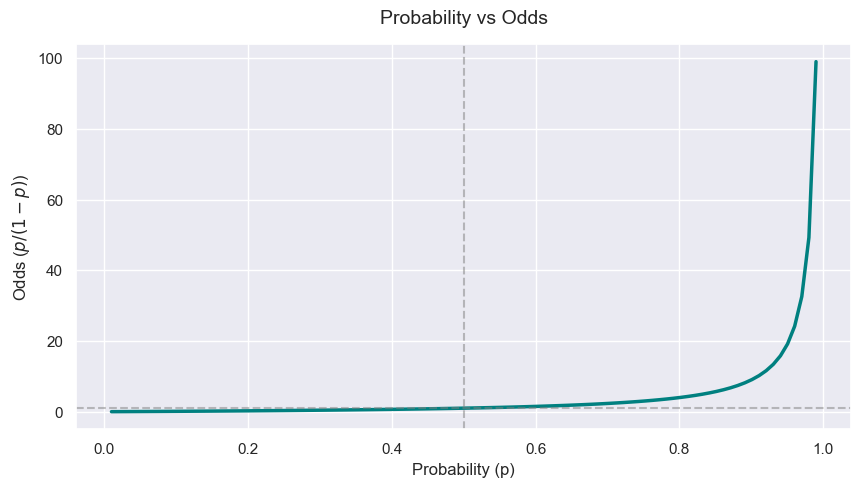

In [5]:
# Generate probabilities from 0.01 to 0.99
p = np.linspace(0.01, 0.99, 100)
odds = p / (1 - p)

# Plotting Probability vs Odds
plt.figure(figsize=(10, 5))
plt.plot(p, odds, color='teal', linewidth=2.5)
plt.title("Probability vs Odds", fontsize=14, pad=15)
plt.xlabel("Probability (p)", fontsize=12)
plt.ylabel("Odds ($p / (1-p)$)", fontsize=12)
plt.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
plt.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
plt.show()

### 4. What are "Log-Odds" (Logit)?
Odds are great, but they are asymmetric:
- Probabilities between $0$ and $0.5$ map to Odds between $0$ and $1$.
- Probabilities between $0.5$ and $1.0$ map to Odds between $1$ and $\infty$.

To make this symmetrical and linear, we take the **natural log** of the Odds. This is called the **Logit function**:
$$\text{Log-Odds} = \log\left(\frac{p}{1-p}\right)$$

Let's look at what this log-transform does:
- If $p = 0.5 \implies \text{Odds} = 1 \implies \log(1) = 0$.
- If $p \to 1 \implies \text{Odds} \to \infty \implies \log(\text{Odds}) \to \infty$.
- If $p \to 0 \implies \text{Odds} \to 0 \implies \log(\text{Odds}) \to -\infty$.

So, Log-Odds range from **$-\infty$ to $+\infty$**!
And guess what? Because the range is now $(-\infty, \infty)$ and symmetric, we can set it equal to our familiar straight line from Linear Regression!
$$\log\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 x$$

This is the fundamental equation of Logistic Regression! If you solve for $p$ in this equation, you get back the Sigmoid function:
$$p = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}}$$

Let's plot Probability vs Log-Odds!

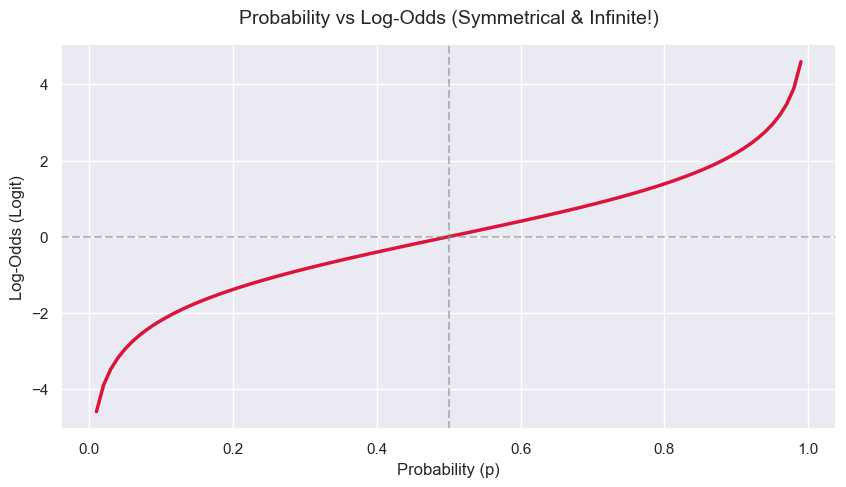

In [6]:
# Compute Log-Odds (Logit)
log_odds = np.log(odds)

# Plotting Probability vs Log-Odds
plt.figure(figsize=(10, 5))
plt.plot(p, log_odds, color='crimson', linewidth=2.5)
plt.title("Probability vs Log-Odds (Symmetrical & Infinite!)", fontsize=14, pad=15)
plt.xlabel("Probability (p)", fontsize=12)
plt.ylabel("Log-Odds (Logit)", fontsize=12)
plt.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
plt.axhline(0.0, color='gray', linestyle='--', alpha=0.5)
plt.show()

### 5. Concept Questions for revision:
1. **Explain in your own words:** Why do we need the Sigmoid function instead of a straight line for classification?
2. **Calculate manually:**
   - If the probability of loan default is $p = 0.2$, what are the Odds and Log-Odds?
   - If a model outputs Log-Odds of $0$, what is the predicted probability $p$?

Write down your notes below!

## ✍️ Your Notes / Answers
> *(Double click this cell to edit and write your notes here)*

1. 
2. 